In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression 
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier


# Selection Bias Example (will bring in this later)

In [142]:

# Set seed for reproducibility
np.random.seed(42)

# Number of samples
n = 10000

# 1. Generate Covariate X (Uniform Distribution between -2 and 2)
X = np.random.uniform(-1, 2, n)

# 2. Assign Treatment A based on X (Propensity Score)
def generate_propensity_score(X, alpha=1.0):
    linear_propensity = alpha * X
    propensity = 1 / (1 + np.exp(-linear_propensity))
    return propensity

propensity_scores = generate_propensity_score(X)
A = np.random.binomial(1, propensity_scores)

# 3. Generate Outcome Y
beta_X = 0.5
beta_A = 3.
sigma = 1.0
Y = beta_X * X + beta_A * A + np.random.normal(0, sigma, n)

# 4. Introduce Severe Selection Bias
gamma_A = 1.    # Very strong effect of A on selection
gamma_Y = 3.    # Very strong inverse effect of Y on selection
gamma_X = 0.0    # No direct effect of X on selection

prob_S = np.zeros(n)

# For X < 1: Selection is random with P(S=1) = 0.5
mask_neg_X = X < 1
prob_S[mask_neg_X] = 0.5

# For X >= 1: Selection depends on A and Y
mask_pos_X = X >= 1
linear_S = gamma_A * A[mask_pos_X] - gamma_Y * Y[mask_pos_X]
prob_S[mask_pos_X] = 1 / (1 + np.exp(-linear_S))

# Generate selection indicator S
S = np.random.binomial(1, prob_S)

# Create DataFrame
data = pd.DataFrame({
    'X': X,
    'A': A,
    'Y': Y,
    'S': S
})

# Select only individuals with S = 1
data_selected = data[data['S'] == 1].reset_index(drop=True)
print(f"Selected Sample Size: {data_selected.shape[0]} out of {n} (Selection Rate: {data_selected.shape[0]/n:.2%})")

# Restrict to X > 1. 
# data_selected = data_selected[data_selected['X'] > 1].reset_index(drop=True)
# print(f"Selected Sample Size: {data_selected.shape[0]} out of {n} (Selection Rate: {data_selected.shape[0]/n:.2%})")

# Resample to match the size of the original sample
# data_selected = data_selected.sample(n=n, replace=True, random_state=42)
# print(f"Resampled Sample Size: {data_selected.shape[0]}")


print(data_selected.head())


Selected Sample Size: 3579 out of 10000 (Selection Rate: 35.79%)
          X  A         Y  S
0  1.124218  0  0.480372  1
1 -0.938247  1  2.126598  1
2 -0.454525  0 -1.663914  1
3  0.295835  1  4.340524  1
4 -0.126313  0 -1.259496  1


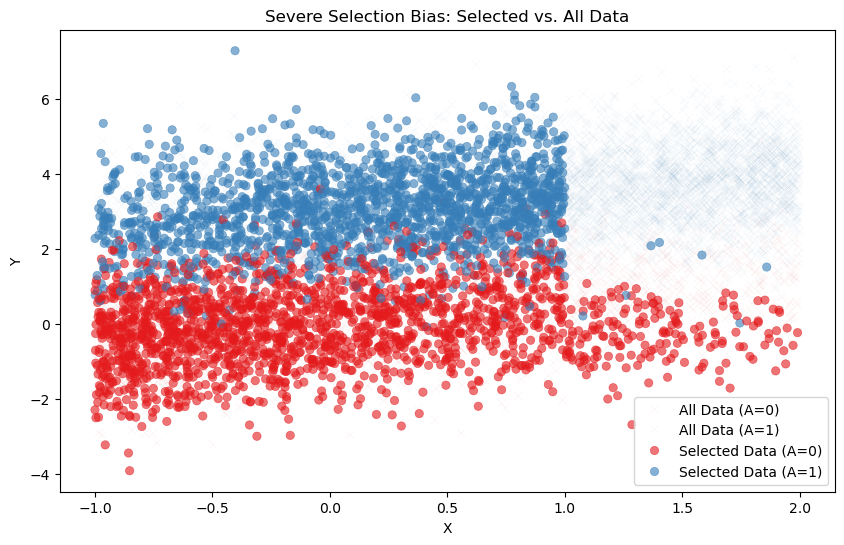

In [143]:
# Plot the data 
plt.figure(figsize=(10, 6))

# Plot all data
sns.scatterplot(x='X', y='Y', hue='A', data=data, alpha=0.05, palette='Set1', marker='x')

# Plot selected data
sns.scatterplot(x='X', y='Y', hue='A', data=data_selected, alpha=0.6, palette='Set1', marker='o', edgecolor=None)

plt.title('Severe Selection Bias: Selected vs. All Data')
plt.xlabel('X')
plt.ylabel('Y')

# Customize the legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['All Data (A=0)', 'All Data (A=1)', 'Selected Data (A=0)', 'Selected Data (A=1)'])

plt.show()


In [144]:
# Estimate propensity scores using logistic regression
X_covariate = sm.add_constant(data_selected['X'])
model_propensity = sm.Logit(data_selected['A'], X_covariate)
result_propensity = model_propensity.fit(disp=0)

# Add propensity scores to the DataFrame
data_selected['propensity_score'] = result_propensity.predict(X_covariate)


In [145]:
# Calculate IPW weights
data_selected['IPW_weight'] = np.where(
    data_selected['A'] == 1,
    1 / data_selected['propensity_score'],
    1 / (1 - data_selected['propensity_score'])
)

In [146]:
# Define interaction term
data_selected['A_X'] = data_selected['A'] * data_selected['X']

# Define predictors
X_model_ipw = sm.add_constant(data_selected[['A', 'X', 'A_X']])

# Fit the weighted regression model
weighted_model_ipw = sm.WLS(data_selected['Y'], X_model_ipw, weights=data_selected['IPW_weight'])
weighted_results_ipw = weighted_model_ipw.fit()

# Display the results
print("\nIPW Estimator Results (Ignoring Selection Bias):")
print(weighted_results_ipw.summary())



IPW Estimator Results (Ignoring Selection Bias):
                            WLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.709
Model:                            WLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     2897.
Date:                Thu, 10 Oct 2024   Prob (F-statistic):               0.00
Time:                        14:36:22   Log-Likelihood:                -5083.2
No. Observations:                3579   AIC:                         1.017e+04
Df Residuals:                    3575   BIC:                         1.020e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

In [147]:
# Now, we can account for selection bias. First, we will compute IPSTW weights.
# Fit selection model
model_selection = sm.Logit(data['S'], sm.add_constant(data[['A', 'Y', 'X']]))
result_selection = model_selection.fit(disp=0)

# Predict selection probabilities for selected data
X_selection = sm.add_constant(data_selected[['A', 'Y', 'X']])
data_selected['selection_prob'] = result_selection.predict(X_selection)

In [148]:
# Calculate IPTSW Weights
data_selected['IPTSW_weight'] = np.where(
    data_selected['A'] == 1,
    1 / (data_selected['propensity_score'] * data_selected['selection_prob']),
    1 / ((1 - data_selected['propensity_score']) * data_selected['selection_prob'])
)


In [149]:
# Fit IPTSW Weighted Regression
X_model_iptsw_ge_1 = sm.add_constant(data_selected[['A', 'X', 'A_X']])
weighted_model_iptsw_ge_1 = sm.WLS(data_selected['Y'], X_model_iptsw_ge_1, weights=data_selected['IPTSW_weight'])
weighted_results_iptsw_ge_1 = weighted_model_iptsw_ge_1.fit()

# Display the results
print("\nIPTSW Estimator Results (Adjusting for Selection Bias):")
print(weighted_results_iptsw_ge_1.summary())



IPTSW Estimator Results (Adjusting for Selection Bias):
                            WLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.714
Model:                            WLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     2979.
Date:                Thu, 10 Oct 2024   Prob (F-statistic):               0.00
Time:                        14:36:42   Log-Likelihood:                -5199.7
No. Observations:                3579   AIC:                         1.041e+04
Df Residuals:                    3575   BIC:                         1.043e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

# OM, PS scenarios w/ model misspecification

In [2]:
# generate the data
np.random.seed(42)
n = 10000 
X_1 = np.random.choice([-1,1],size=(n,)) # binary covariate (observed)
U_1 = np.random.choice([-1,1],size=(n,)) # unobserved covariate 



## Scenario 1: PS bad, OM good

In [3]:
# generate scenario-specific data, A and Y 
A_scenario1 = np.zeros(n)

# When X1 = 0
mask_X1_0 = X_1 == -1
A_scenario1[mask_X1_0] = np.random.binomial(1, 0.1, mask_X1_0.sum()) #0.5

# When X1 = 1, A depends on U1
mask_X1_1 = X_1 == 1
prob_A_given_U1 = np.where(U_1[mask_X1_1] == 1, 0.9, 0.1) #0.8, 0.2
A_scenario1[mask_X1_1] = np.random.binomial(1, prob_A_given_U1)

# Y depends on X1, A, and noise
beta_0 = 0 
beta_X1 = 1 
beta_A = 1 

epsilon = np.random.normal(0, 1, n) * 0.01
Y_scenario1 = np.zeros(A_scenario1.shape)
Y_scenario1[A_scenario1 == 0] = epsilon[A_scenario1 == 0]
Y_scenario1[(A_scenario1 == 1) & (X_1 == -1)] = (X_1 + epsilon)[(A_scenario1 == 1) & (X_1 == -1)]
Y_scenario1[(A_scenario1 == 1) & (X_1 == 1)] = (1 + X_1 + U_1 + epsilon)[(A_scenario1 == 1) & (X_1 == 1)]
#Y_scenario1 = beta_0 + beta_X1 * X_1 + beta_A * A_scenario1 + epsilon

data_scenario1 = pd.DataFrame({
    'X1': X_1,
    'A': A_scenario1,
    'Y': Y_scenario1
})

In [ ]:
# plot Y as a function of X1 colored by A
plt.figure(figsize=(10, 6))
sns.scatterplot(x='X1', y='Y', hue='A', data=data_scenario1, palette={0: 'tab:red', 1: 'tab:blue'})
plt.title('Y as a function of X1, colored by A')
plt.xlabel('X1')
plt.ylabel('Y')
plt.legend(title='A', labels=['0', '1'])
plt.show()


In [4]:
# Fit logistic regression of A on X1
psm_s1 = LogisticRegression(C=1.).fit(data_scenario1['X1'].values.reshape(-1,1), data_scenario1['A'].values)
om_s1_A0  = LinearRegression().fit(data_scenario1.query('A==0')['X1'].values.reshape(-1,1), 
                                        data_scenario1.query('A==0')['A'].values)
om_s1_A1  = LinearRegression().fit(data_scenario1.query('A==1')['X1'].values.reshape(-1,1), 
                                        data_scenario1.query('A==1')['A'].values)
data_scenario1['hat_Y0'] = om_s1_A0.predict(data_scenario1['X1'].values.reshape(-1,1))
data_scenario1['hat_Y1'] = om_s1_A1.predict(data_scenario1['X1'].values.reshape(-1,1))
data_scenario1['SE_Y0'] = (data_scenario1.query('A==0')['Y'] - data_scenario1.query('A==0')['hat_Y0'])**2
data_scenario1['SE_Y1'] = (data_scenario1.query('A==1')['Y'] - data_scenario1.query('A==1')['hat_Y1'])**2

mseloss_t0 = np.zeros(2)
mseloss_t0[0] = data_scenario1.query("X1==-1 & A==0")["SE_Y0"].dropna().mean()
mseloss_t0[1] = data_scenario1.query("X1==1 & A==0")["SE_Y0"].dropna().mean()
print(mseloss_t0)

mseloss_t1 = np.zeros(2)
mseloss_t1[0] = data_scenario1.query("X1==-1 & A==1")["SE_Y1"].dropna().mean()
mseloss_t1[1] = data_scenario1.query("X1==1 & A==1")["SE_Y1"].dropna().mean()
print(mseloss_t1)


[9.77059651e-05 1.02296442e-04]
[4.00111669 3.57712552]


## Scenario 2: PS good, OM bad

In [22]:
# Treatment assignment depends only on X1
prob_A_scenario2 = np.where(X_1 == 1, 0.7, 0.3)
A_scenario2 = np.random.binomial(1, prob_A_scenario2)


In [23]:
beta_0 = 0
beta_A = 2
beta_U1 = 1

epsilon = np.random.normal(0, 1, n)
Y_scenario2 = np.zeros(n)

# When X1 = 0, Y depends on A and noise
mask_X1_0 = X_1 == -1
Y_scenario2[mask_X1_0] = beta_0 + beta_A * A_scenario2[mask_X1_0] + epsilon[mask_X1_0]

# When X1 = 1, Y depends on A, U1, and noise
mask_X1_1 = X_1 == 1
Y_scenario2[mask_X1_1] = beta_0 + beta_A * A_scenario2[mask_X1_1] + beta_U1 * U_1[mask_X1_1] + epsilon[mask_X1_1]


In [24]:
data_scenario2 = pd.DataFrame({
    'X1': X_1,
    'A': A_scenario2,
    'Y': Y_scenario2
})


In [25]:
# Fit logistic regression of A on X1
psm_s1 = LogisticRegression(C=1.).fit(data_scenario2['X1'].values.reshape(-1,1), data_scenario2['A'].values)
om_s1_A0  = LinearRegression().fit(data_scenario2.query('A==0')['X1'].values.reshape(-1,1), 
                                        data_scenario2.query('A==0')['A'].values)
om_s1_A1  = LinearRegression().fit(data_scenario2.query('A==1')['X1'].values.reshape(-1,1), 
                                        data_scenario2.query('A==1')['A'].values)
data_scenario2['hat_Y0'] = om_s1_A0.predict(data_scenario2['X1'].values.reshape(-1,1))
data_scenario2['hat_Y1'] = om_s1_A1.predict(data_scenario2['X1'].values.reshape(-1,1))
data_scenario2['SE_Y0'] = (data_scenario2.query('A==0')['Y'] - data_scenario2.query('A==0')['hat_Y0'])**2
data_scenario2['SE_Y1'] = (data_scenario2.query('A==1')['Y'] - data_scenario2.query('A==1')['hat_Y1'])**2

mseloss_t0 = np.zeros(2)
mseloss_t0[0] = data_scenario2.query("X1==-1 & A==0")["SE_Y0"].dropna().mean()
mseloss_t0[1] = data_scenario2.query("X1==1 & A==0")["SE_Y0"].dropna().mean()
print(mseloss_t0)

mseloss_t1 = np.zeros(2)
mseloss_t1[0] = data_scenario2.query("X1==-1 & A==1")["SE_Y1"].dropna().mean()
mseloss_t1[1] = data_scenario2.query("X1==1 & A==1")["SE_Y1"].dropna().mean()
print(mseloss_t1)

[0.9587093  2.04558052]
[1.96227778 2.93422587]


# Deprecated

In [ ]:
# import statsmodels.api as sm

# propensity_model_s1 = sm.Logit(data_scenario1['A'], sm.add_constant(data_scenario1['X1']))
# result_propensity_s1 = propensity_model_s1.fit(disp=0)

# # Display summary
# print("Scenario 1 Propensity Score Model:")
# print(result_propensity_s1.summary())

# # Evaluate the model
# X_with_const = sm.add_constant(data_scenario1['X1'])
# predicted_probs = result_propensity_s1.predict(X_with_const)
# predicted_treatments = (predicted_probs > 0.5).astype(int)

# # Calculate accuracy
# accuracy = (predicted_treatments == data_scenario1['A']).mean()

# print(f"\nPropensity Score Model Accuracy: {accuracy:.4f}")